![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [6]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
----------------------------------------
✓ numpy 2.4.4
✓ pandas 3.0.2
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [7]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1:**
    La latencia para este laboratorio representa, el tiempo de respuesta o el tiempo de acceso en la operación de lectura o escritura en el disco, desde que se realiza la solicitud de lectura o escritura hasta que comienza la operación de transferencia de datos.
- **Respuesta 2:** El throughput o también llamado el ancho de banda, es la cantidad total de trabajo o información transferida en un tiempo dado, en el contexto del laboratorio, es la cantidad de bytes por unidad de tiempo transferidos en el disco cuando se ejecuta una operación de lectura o escritura, o también se puede decir que es la tasa de transferencia de información en un disco. 
- **Respuesta 3:** se asume 1 por que solo hay un costo inicial al bloque inicial, mientras que los bloques contiguos no se requiere el costo de acceso o seek.
- **Respuesta 4:** el número de accesos no contiguos al disco tiende a ser mayor, porque para cada bloque se requiere reposicionamiento o un costo de acceso individual o seek individual.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [55]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 512 * 24

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data/dataset.bin
Tamaño objetivo (MB): 12288
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1:** El archivo de 512 MB no es suficiente para superar la caché RAM de mi equipo, ya que la memoria disponible es de 1.0 GB. Para evitar el cacheo y medir el verdadero rendimiento del disco, se necesitaría un archivo de al menos > 8 GB (superior a la RAM total). En mi caso, con 7.6 GB de RAM, un archivo de 10 GB sería adecuado.
- **Respuesta 2:** El tamaño de bloque de 256 KB debería tener el mejor rendimiento en acceso aleatorio. Ya que, en rl acceso aleatorio, cada bloque leído requiere una operación de E/S independiente, y cada operación paga una latencia fija en virtud al modelo de costo.
- **Respuesta 3:** Ejecuto en local (Debian). Estoy corriendo el código en mi máquina, como se ve por los valores de RAM y el sistema operativo que reporté. Por tanto, las mediciones reflejan mi hardware.

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [97]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = True  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

Carpeta io_lab_data eliminada. El archivo se recreará en la siguiente sección.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [56]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 12288 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 12884901888


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1:** El archivo dataset.bin es el conjunto de datos de prueba sobre el cual se realizarán todas las mediciones de rendimiento de E/S. Actúa como un "disco de datos" artificial que contiene información sintética. Durante el experimento, el programa leerá desde este archivo usando diferentes tamaños de bloque y patrones de acceso (secuencial o aleatorio), para medir tiempos de lectura y calcular throughput y latencia efectiva. Sin este archivo, no habría datos que leer; es la fuente de carga de trabajo del laboratorio.
- **Respuesta 2:** Trabajar con un archivo de cientos de megabytes (o varios gigabytes) es útil porque supera (o puede superar) la caché del SO si el tamaño es mayor que la memoria RAM disponible. Esto fuerza a que las lecturas realmente vayan al disco (o SSD) y no se sirvan desde la caché, dando mediciones más realistas del rendimiento físico. Además, con un archivo pequeño, incluso los accesos aleatorios pueden caer dentro de una región pequeña que el disco puede cachear completamente, ocultando las diferencias entre acceso secuencial y aleatorio. También, al leer muchos bloques, el tiempo total es suficientemente grande para que las mediciones sean estables y repetibles, minimizando el impacto de fluctuaciones del sistema.Por último, as bases de datos y aplicaciones grandes trabajan con volúmenes de datos que no caben enteros en RAM, por lo que usar un archivo grande simula mejor esas condiciones.
- **Respuesta 3:** Si el archivo fuera demasiado pequeño, el archivo completo cabría fácilmente en la caché del sistema operativo después de la primera lectura. Esto haría que todas las lecturas posteriores (tanto secuenciales como aleatorias) se sirvieran desde la caché de RAM en lugar de desde el disco real. Además, las diferencias entre acceso secuencial y aleatorio se difuminarían porque la latencia de la RAM es  menor que la de un disco SSD (mi caso), y el throughput de la caché es muchísimo más alto. Por último, los resultados empíricos no reflejarían el comportamiento real del dispositivo de almacenamiento, sino el rendimiento de la memoria RAM y del algoritmo de gestión de caché del kernel. Por lo tanto, las conclusiones sobre el impacto del tamaño de bloque o del patrón de acceso serían engañosas o directamente inválidas para predecir el desempeño en sistemas con datasets grandes.

## 5. Funciones auxiliares de medición

In [27]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [60]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical



Probando bloque = 4.00 KB
Secuencial -> tiempo: 46.1003 s, throughput: 266.55 MiB/s
Aleatorio  -> tiempo: 0.6993 s, throughput: 22.34 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 44.7976 s, throughput: 274.30 MiB/s
Aleatorio  -> tiempo: 0.9071 s, throughput: 68.90 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 47.5776 s, throughput: 258.27 MiB/s
Aleatorio  -> tiempo: 1.7373 s, throughput: 143.90 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 56.7530 s, throughput: 216.52 MiB/s
Aleatorio  -> tiempo: 3.8587 s, throughput: 259.15 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,12884901888,3145728,46.100310,266.549185,4.0
1,Aleatorio,4096,16384000,4000,0.699318,22.343207,4.0
2,Secuencial,16384,12884901888,786432,44.797601,274.300404,16.0
3,Aleatorio,16384,65536000,4000,0.907091,68.901603,16.0
4,Secuencial,65536,12884901888,196608,47.577597,258.272816,64.0
5,Aleatorio,65536,262144000,4000,1.737345,143.897750,64.0
6,Secuencial,262144,12884901888,49152,56.753029,216.517076,256.0
7,Aleatorio,262144,1048576000,4000,3.858741,259.151855,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

1. Para bloques de 4 KB, 16 KB y 64 KB, el acceso secuencial fue más rápido. Para bloque de 256 KB, sorprendentemente el acceso aleatorio fue ligeramente más rápido (259.15 MiB/s vs 216.52 MiB/s). Esto podría deberse a que en la prueba secuencial se leyeron 12 GB (no caben en caché) mientras que en la aleatoria se leyeron 1 GB (quizás parcialmente cacheado), o a características del disco/SSD con bloques muy grandes.

2. Sí, el throughput cambia. En secuencial se mantiene alto y luego baja ligeramente; en aleatorio crece sostenidamente con el tamaño de bloque. Para el caso del secuencial el throughput se mantuvo alto entre 4 KB y 64 KB (≈260–274 MiB/s), pero cayó a 216.5 MiB/s con bloque de 256 KB. En cuanto al acceso aleatorio, al throughput aumentó drásticamente al crecer el bloque, es decir, para bloques de 4 KB este es de 22.34 MiB/s,luego para bloques 16 KB el throughput es de 68.90 MiB/s, y asi va aumentanto, hasta llegar a 259.15 MiB/s para un bloque de 256 KB

3. La mayor diferencia entre secuencial y aleatorio se observó con el tamaño de bloque de 4 KB. Allí el acceso secuencial fue 12 veces más rápido que el aleatorio. Conforme aumenta el bloque, la diferencia se reduce y finalmente se invierte para 256 KB (aleatorio más rápido).

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [87]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 100e-6,
    'scan_throughput_bytes_s': 500 * (1024**2),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 0.0001, 'scan_throughput_bytes_s': 524288000}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD
- Latencia asumida: $100^{-6}$
- Throughput asumido: $500 \cdot {1024^{3}}$

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

In [88]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,24.57610,499.997966
1,Aleatorio,4096,4.0,0.43125,36.231884
2,Secuencial,16384,16.0,24.57610,499.997966
3,Aleatorio,16384,16.0,0.52500,119.047619
4,Secuencial,65536,64.0,24.57610,499.997966
5,Aleatorio,65536,64.0,0.90000,277.777778
6,Secuencial,262144,256.0,24.57610,499.997966
7,Aleatorio,262144,256.0,2.40000,416.666667


## 8. Comparación entre resultados empíricos y teóricos

In [89]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,12884901888,3145728,46.100310,266.549185,4.0,24.57610,499.997966,1.875819,0.533101
1,Aleatorio,4096,16384000,4000,0.699318,22.343207,4.0,0.43125,36.231884,1.621606,0.616673
2,Secuencial,16384,12884901888,786432,44.797601,274.300404,16.0,24.57610,499.997966,1.822812,0.548603
3,Aleatorio,16384,65536000,4000,0.907091,68.901603,16.0,0.52500,119.047619,1.727792,0.578773
4,Secuencial,65536,12884901888,196608,47.577597,258.272816,64.0,24.57610,499.997966,1.935930,0.516548
5,Aleatorio,65536,262144000,4000,1.737345,143.897750,64.0,0.90000,277.777778,1.930383,0.518032
6,Secuencial,262144,12884901888,49152,56.753029,216.517076,256.0,24.57610,499.997966,2.309277,0.433036
7,Aleatorio,262144,1048576000,4000,3.858741,259.151855,256.0,2.40000,416.666667,1.607809,0.621964


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

1. Los tiempos empíricos son mayores que los teóricos en todos los casos, es decir, el SSD real se comporta peor que el modelo teórico idealizado.El SSD real es entre 1.6 y 2.3 veces más lento de lo que predice el modelo teórico.

2. La teoría se aproxima mejor en acceso aleatorio, especialmente con bloques pequeños (4 KB) y grandes (256 KB). El menor ratio empírico/teórico se da en aleatorio de 256 KB: 1.61 (tiempo real 3.86 s vs teórico 2.40 s). Le sigue aleatorio de 4 KB: 1.62 (0.70 s vs 0.43 s). En cambio, en secuencial los ratios son más altos (1.82 a 2.31), siendo secuencial de 256 KB el que más se aleja (2.31). Por tanto, el modelo teórico predice mejor el comportamiento aleatorio que el secuencial en este SSD.

3. Entre los factores se puede encontrar, Throughput real del SSD inferior al declarado, El modelo asume 500 MB/s de lectura secuencial, pero las mediciones empíricas dan entre 216 y 274 MiB/s (~227–287 MB/s). Esto indica que el ADATA de 256 GB (probablemente un modelo de gama baja o media) no alcanza la velocidad teórica de 500 MB/s debido a limitaciones del controlador, tipo de memoria NAND o interfaz SATA real. Esta diferencia explica por qué los tiempos secuenciales empíricos son casi el doble de los teóricos. Luego esta la latencia real mayor a 100 µs y sobrecarga de acceso aleatorio El modelo asume 100 µs por acceso aleatorio. Por ultimo, otro factir es  la caché del sistema operativo y efecto de múltiples pasadas. 

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [90]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: /home/juan1993/Documentos/Cursos Universidad/Estructura fisica de la informacion/Laboratorio_3/lab3-IO_perfomance-JuanCamiloMonaLujan/images


Guardada: fig_throughput.png


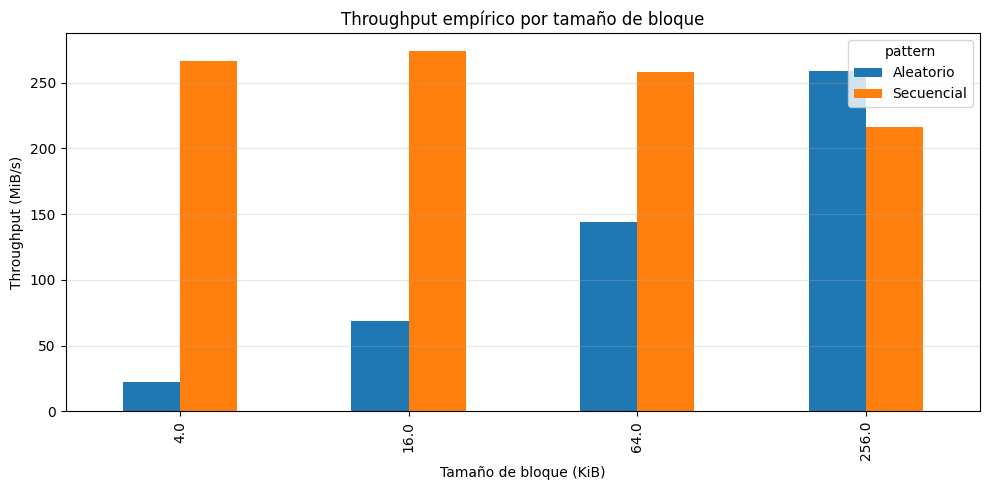

In [91]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

- **¿Qué barras son más altas?**
Las barras naranjas (secuencial) son consistentemente más altas en los tres primeros tamaños de bloque. En 4 KiB, la diferencia es dramática: ~265 MiB/s (secuencial) vs ~22 MiB/s (aleatorio). En 16 KiB: ~275 MiB/s vs ~68 MiB/s. En 64 KiB: ~258 MiB/s vs ~143 MiB/s.

- **Significado en términos de rendimiento:**
Esto indica que el acceso secuencial aprovecha mucho mejor la localidad espacial y el prefetching del hardware (caché, controlador de disco). El patrón secuencial permite lecturas anticipadas y minimiza el tiempo de búsqueda (seek time), mientras que el acceso aleatorio genera constantes tiempos de búsqueda.
- **¿Cuál patrón aprovecha mejor la lectura en bloques?**
El patrón secuencial, especialmente con bloques pequeños. Por ejemplo, con 4 KiB, el throughput secuencial (265 MiB/s) es aproximadamente 12 veces superior al aleatorio (22 MiB/s).
Curiosamente, en 256 KiB, las barras se invierten: el acceso aleatorio (258 MiB/s) supera ligeramente al secuencial (216 MiB/s). Esto sugiere que con bloques muy grandes, el overhead de seek time se amortiza, y posiblemente el prefetching secuencial ya no aporta ventaja adicional.


Guardada: fig_tiempo_empirico.png


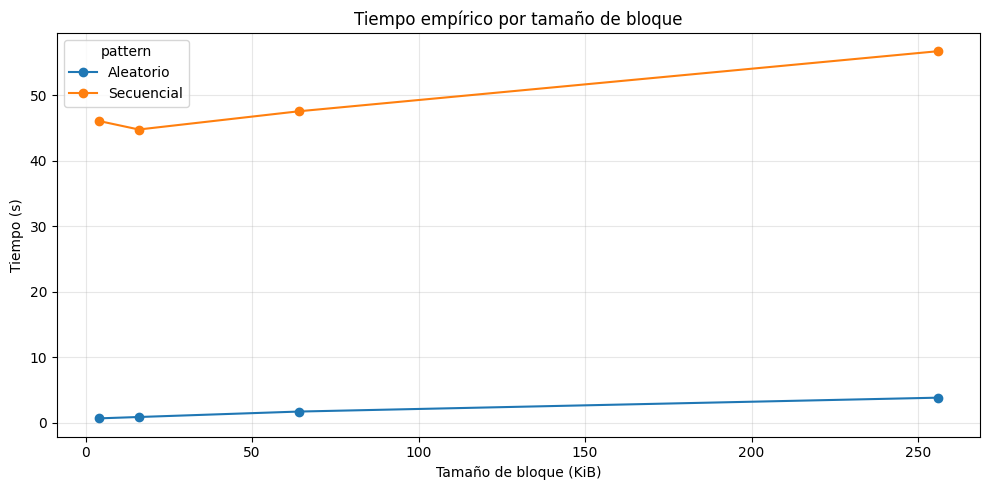

In [96]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

Las curvas ya parten muy separadas y mantienen esa brecha. El punto de mayor divergencia absoluta ocurre en el tamaño de bloque más grande (256 KiB), donde la diferencia es de aproximadamente 52 segundos (56s vs 3.7s).
Sin embargo, el factor de diferencia relativa es máximo en bloques pequeños: en 4 KiB, el secuencial tarda 46s vs 0.5s del aleatorio — una diferencia de 92 veces en tiempo.
Observación importante: El tiempo total del acceso aleatorio es sorprendentemente bajo. Esto sugiere que la cantidad total de datos transferidos podría ser menor en el patrón aleatorio, o que hay alguna optimización del sistema de archivos/caché que beneficia especialmente al acceso aleatorio con bloques grandes.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


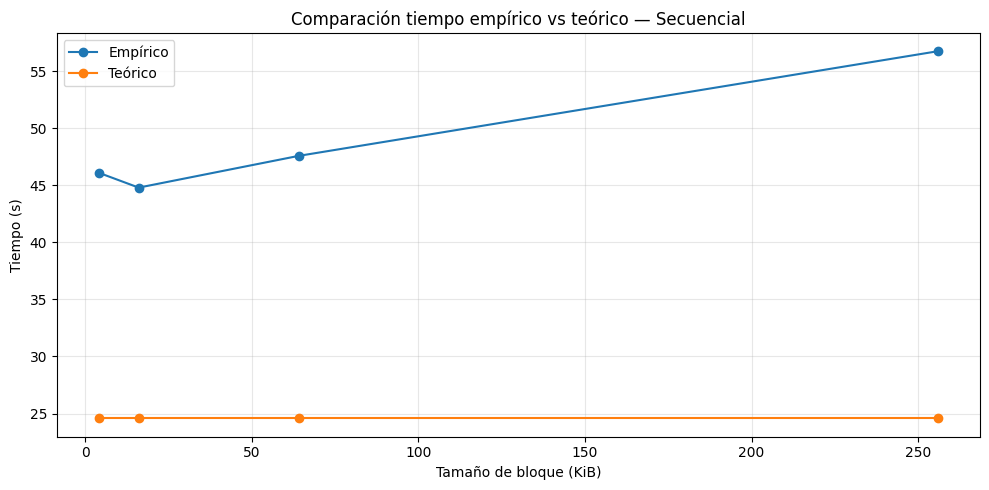

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


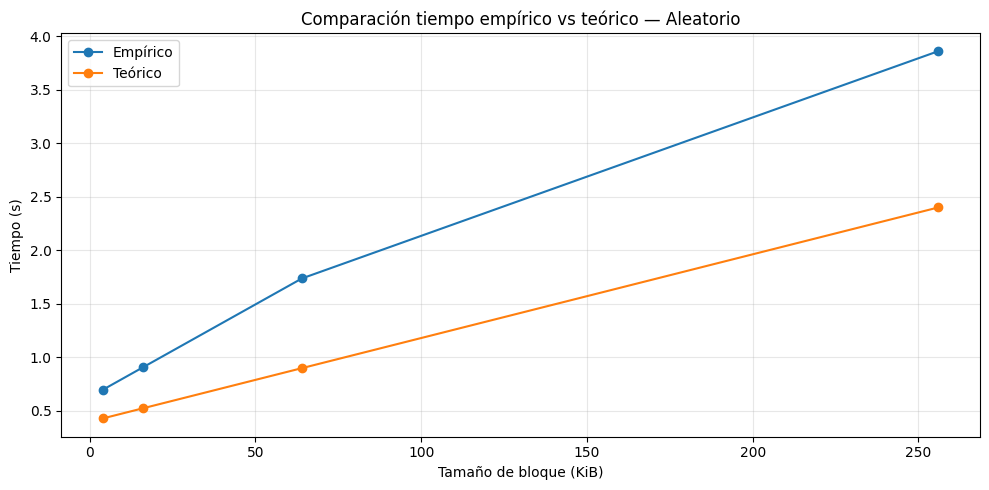

In [93]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

**1. ¿Las curvas tienen una tendencia similar?**

Para el acceso aleatorio ambas curvas crecen linealmente con el tamaño de bloque, mientras que en el secuencial, no se tiene una tendencia similar, ya el teórico es prácticamente constante (24.5s), mientras el empírico crece linealmente

**2. ¿Dónde se separan más?**

En el acceso aleatorio la separación máxima se da en aproximadamente 256 KiB, donde empírico (3.85s) vs teórico (2.4s). En el acceso secuencial en aproximadamente 256 KiB, hay una diferencia de más de 30 segundos (56.5s vs 24.5s). 

**3. ¿Qué le sugiere eso sobre el modelo usado?**

Para el acceso aleatorio el modelo subestima el tiempo real, mientras que en el acceso secuencual subestima gravemente el tiempo real

Guardada: fig_speedup.png


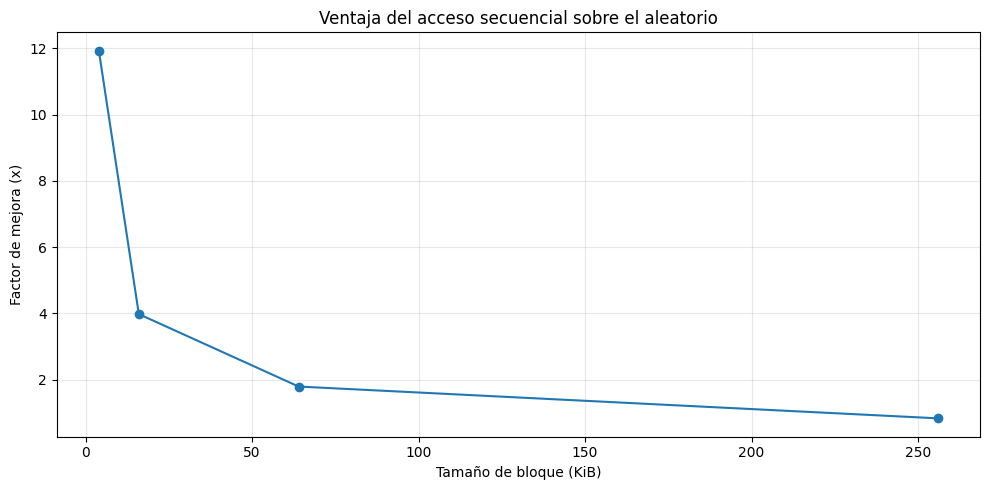

In [94]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta


 **¿Cuál fue el mayor factor de mejora observado?**
 
El mayor speedup observado fue de 12x (aproximadamente 12 veces), ocurriendo en el tamaño de bloque más pequeño (4 KiB o ligeramente menos).
 
 **¿Cómo cambia esa ventaja con el tamaño de bloque?**
 
 | Tamaño de bloque | Factor de mejora          |
| ---------------- | ------------------------- |
| ~4 KiB           | **~12x**                  |
| ~16 KiB          | ~4x                       |
| ~64 KiB          | ~1.8x                     |
| ~256 KiB         | ~0.9x (ventaja invertida) |

    
 **¿Qué implicación tiene esto para el diseño de software?**
 
- Bloques pequeños + acceso secuencial = máximo rendimiento: Para I/O intensivo, usar lecturas secuenciales con bloques de 4-16 KiB optimiza el uso del caché y prefetching.
- Evitar acceso aleatorio con bloques pequeños: Es catastróficamente lento (12x más lento que secuencial).
- Trade-off en bloques grandes: Con 256 KiB, el acceso aleatorio puede ser comparable o incluso ligeramente superior, sugiriendo que para transferencias masivas de datos grandes, el patrón de acceso importa menos que el tamaño del bloque en sí.
- Diseño de estructuras de datos: Favorecer layouts contiguos en disco (arrays, archivos planos) sobre estructuras dispersas (listas enlazadas, tablas hash en disco) cuando el rendimiento de lectura sea crítico.


## 10. Resumen automático de resultados

In [95]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,46.100310,0.699318,266.549185,22.343207,11.929764
1,16.0,44.797601,0.907091,274.300404,68.901603,3.981045
2,64.0,47.577597,1.737345,258.272816,143.897750,1.794836
3,256.0,56.753029,3.858741,216.517076,259.151855,0.835483


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

Escriba aquí su conclusión final.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.